In [1]:
import cv2
import pytesseract
import matplotlib.pyplot as plt
import numpy as np
import re
import glob
import random
from skimage.color import deltaE_ciede2000, rgb2lab

# Several images:

In [2]:
def process_image (image):
    # Preprocess the image (convert to grayscale and apply thresholding)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

    # Use Tesseract to do OCR on the image
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(thresh, config=custom_config)
    return thresh, text


def process_region(region):
    # Preprocess the image (convert to grayscale and apply thresholding)
    thresh, text = process_image(region)
    numbers = re.findall(r"\d+\.?\d*", text)
    # add decimal point if there isn't
    for i in range(len(numbers)):
        if len(numbers[i]) == 3:
            numbers[i] = numbers[i][:2] + "." + numbers[i][2]
    return numbers

In [3]:
def all_images (path, plot=True):
    # Iterate through each image in the folder
    print(f"Processing: {path}")

    image = cv2.imread(path)
    if image is None:
        print(f"Error loading image: {path}")
        return
      
    if image.shape[1] > image.shape[0]: #landscape
        u = [10, 130, 80, 50]
        l = [10, 385, 80, 50]
    else:
        u = [10, 130, 80, 50]
        l = [10, 450, 80, 50]
    
    ux, uy, uw, uh = u  # Upper region
    lx, ly, lw, lh = l  # Lower region
    
    # image[y:y+h, x:x+w]
    square_region_upper = image[uy:uy+uh, ux:ux+uw]
    square_region_lower = image[ly:ly+lh, lx:lx+lw]
    
    if plot:
        plt.figure(figsize=(3, 1))  # Adjust size for better visualization
        
        plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
        plt.imshow(cv2.cvtColor(square_region_upper, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
        plt.imshow(cv2.cvtColor(square_region_lower, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    numbers = process_region(square_region_upper)
    numbers2 = process_region(square_region_lower)
    
    if plot:
        if len(numbers) > 0 and len(numbers2) > 0:
            print(f"   Max Value: {max(numbers)}           |       Min Value: {min(numbers2)}")
            return float(max(numbers)), float(min(numbers2))
        
        elif numbers == []:
            print(f"Min Value: {min(numbers2)}")
            print("No max value detected")
        elif numbers2 == []:
            print(f"Max Value: {max(numbers)}")
            print("No min value detected")

        print("-" * 100)  # Separator for readability
    else: 
        return float(max(numbers)), float(min(numbers2))


## Horizontal:

In [4]:
folder_path_horizontal = "/home/martina/codi2/50_02.12.24-03.12.24/*.jpeg"

# Get a list of all image files in the folder
image_paths_horizontal = sorted(glob.glob(folder_path_horizontal))

print(len(image_paths_horizontal)) 


500


Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215013.jpeg


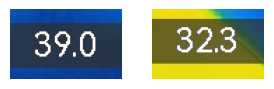

   Max Value: 39.0           |       Min Value: 32.3
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215114.jpeg


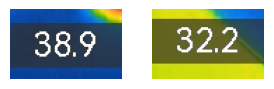

   Max Value: 38.9           |       Min Value: 32.2
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215215.jpeg


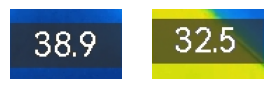

   Max Value: 38.9           |       Min Value: 32.5
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215317.jpeg


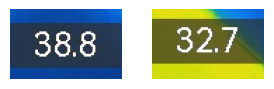

   Max Value: 38.8           |       Min Value: 32.7
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215418.jpeg


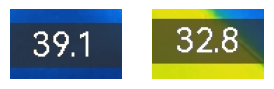

   Max Value: 39.1           |       Min Value: 32.8
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215519.jpeg


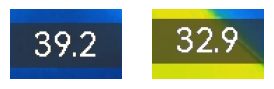

   Max Value: 39.2           |       Min Value: 32.9
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215620.jpeg


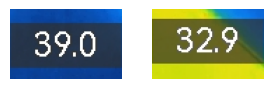

   Max Value: 39.0           |       Min Value: 32.9


In [5]:
for path in image_paths_horizontal[43:50]:
    all_images(path)

## Vertical:


In [6]:
folder_path_vertical = "/home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/*.jpg"

# Get a list of all image files in the folder
image_paths_vertical = sorted(glob.glob(folder_path_vertical))

print(len(image_paths_vertical)) 


7


Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240815233312_.jpg


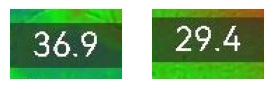

   Max Value: 36.9           |       Min Value: 29.4
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816005549_.jpg


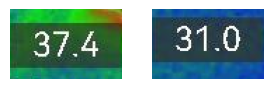

   Max Value: 37.4           |       Min Value: 31.0
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816011016_.jpg


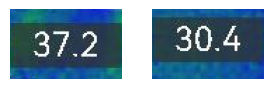

   Max Value: 37.2           |       Min Value: 30.4
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816030018_.jpg


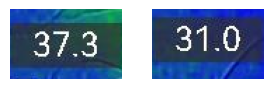

   Max Value: 37.3           |       Min Value: 31.0
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816050859_.jpg


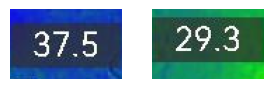

   Max Value: 37.5           |       Min Value: 29.3
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816065935_.jpg


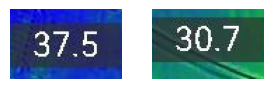

   Max Value: 37.5           |       Min Value: 30.7
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816074705_.jpg


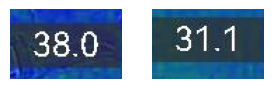

   Max Value: 38.0           |       Min Value: 31.1


In [7]:
for path in image_paths_vertical[:7]:
    all_images(path)

## Different formats and colors:

In [8]:
folder_path = "/home/martina/codi2/3year/synthesisII/diferent/*.jpeg"

# Get a list of all image files in the folder
image_paths = sorted(glob.glob(folder_path))

print(len(image_paths)) 

8


Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20240815055937.jpeg


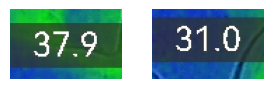

   Max Value: 37.9           |       Min Value: 31.0
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20240815062318.jpeg


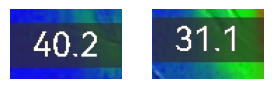

   Max Value: 40.2           |       Min Value: 31.1
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202060956.jpeg


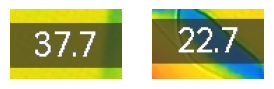

   Max Value: 37.7           |       Min Value: 22.7
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202065451.jpeg


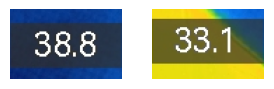

   Max Value: 38.8           |       Min Value: 33.1
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202081023.jpeg


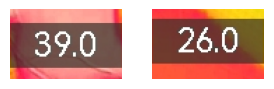

   Max Value: 39.0           |       Min Value: 26.0
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202081529.jpeg


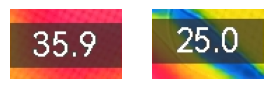

   Max Value: 35.9           |       Min Value: 25.0
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202093407.jpeg


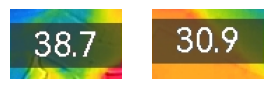

   Max Value: 38.7           |       Min Value: 30.9
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202100444.jpeg


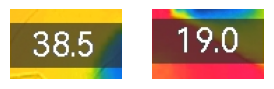

   Max Value: 38.5           |       Min Value: 19.0


In [9]:
for path in image_paths[:]:
    all_images(path)

# Grayscale:

We have noticed that the points with red color give lower temperatures than they should:

The color mapping from the thermal image might cause some issues when translating it to grayscale because the color-to-grayscale translation does not preserve the same temperature order


thermal image from hottest temperature to lowest are: white, red, orange, yellow, green, blue, purple/black. 

ordered colors in grayscale from darkest to whitest: black, blue, red, magenta, gray, green, cyan, yellow, white

In [ ]:
import numpy as np
from skimage.color import rgb2lab, deltaE_ciede2000
from joblib import Parallel, delayed

def color_to_temp_to_grayscale(image, max_temp, min_temp):
    # Define a fine-grained normalized temperature-to-color mapping TO PRESERVE THE ORDER OF THE TEMPERATURE SCALE. 
    # DICTIONARY GOES FROM 0 TO 1 SO THAT WE CAN USE THE MAX AND MIN TEMPERATURE VALUES TO NORMALIZE THE TEMPERATURES FOR EACH PICTURE ACCORDINGLY
    temperature_colors = {
        0.00: (75, 0, 130),    # Purple/Black (coldest)
        0.10: (0, 0, 200),     # Deep Blue
        0.20: (0, 0, 255),     # Blue
        0.30: (0, 128, 255),   # Light Blue
        0.40: (0, 255, 0),     # Green
        0.50: (173, 255, 47),  # Yellow-Green
        0.60: (255, 255, 0),   # Yellow
        0.70: (255, 200, 0),   # Dark Yellow/Orange
        0.75: (255, 165, 0),   # Orange
        0.80: (255, 100, 0),   # Deep Orange
        0.90: (255, 0, 0),     # Red
        0.95: (255, 100, 100), # Light Red
        1.00: (255, 255, 255)  # White (hottest)
    }
    
    # Convert dictionary to numpy arrays for processing
    normalized_temps = np.array(list(temperature_colors.keys())) # keys
    colors = np.array(list(temperature_colors.values()), dtype=np.uint8) # values
    
    # RGB to LAB because CIEDE2000 is more accurate in the LAB color space
    # LAB: difference between two colors in Lab space corresponds to how humans perceive the difference.
    # deltaE_ciede2000 computes the perceptual diff between two colors in LAB. this is so that we can find the closest color in the dictionary to each pixel
    colors_lab = rgb2lab(colors.reshape(1, -1, 3)).reshape(-1, 3)
    image_reshaped = image.reshape(-1, 3).astype(np.uint8)
    image_lab = rgb2lab(image_reshaped.reshape(1, -1, 3)).reshape(-1, 3)
    
    # split the image into chunks for parallel processing (function below)
    num_chunks = 8
    chunks = np.array_split(image_lab, num_chunks)
    
    def process_chunk(chunk):
        # Reshape chunk and colors_lab for broadcasting
        chunk_expanded = chunk[:, np.newaxis, :]  # Shape: (N_pixels_in_chunk, 1, 3)
        colors_lab_expanded = colors_lab[np.newaxis, :, :]  # Shape: (1, N_colors, 3)
        
        # compute difference for all pixels in the chunk and all colors in the dictionary
        distances = deltaE_ciede2000(chunk_expanded, colors_lab_expanded)  # Shape: (N_pixels_in_chunk, N_colors)
        
        closest_indices = np.argmin(distances, axis=1) # get closest color with the smallest deltaE (difference)
        return normalized_temps[closest_indices]
    
    # Process chunks in parallel
    results = Parallel(n_jobs=-1)(delayed(process_chunk)(chunk) for chunk in chunks)
    temperature_map = np.concatenate(results) # Concatenate the results
    
    # Reshape back to image dimensions
    temperature_map = temperature_map.reshape(image.shape[:2])
    
    # normalized temperature --> actual temperature range
    actual_temp_values = temperature_map * (max_temp - min_temp) + min_temp
    
    # tewmperature range --> grayscale (0-255) ensuring red (high temp) is white and blue (low temp) is black
    grayscale_image = np.clip((actual_temp_values - min_temp) / (max_temp - min_temp) * 255, 0, 255).astype(np.uint8)
    
    return grayscale_image

def normalize(value, min_val, max_val, new_min, new_max):
    return new_min + (value - min_val) * (new_max - new_min) / (max_val - min_val)

def check_correlation(path):
        image_normal = cv2.imread(path)
        if image_normal is None:
            print(f"Error loading image: {path}")
            return
        
        image = cv2.cvtColor(image_normal, cv2.COLOR_BGR2RGB)
        max_temp, min_temp = all_images(path, plot=False) # get the max and min values from the image
        
        # print(f"Max Temp: {max_temp} - Min Temp: {min_temp}")
        grayscale_image = color_to_temp_to_grayscale(image, max_temp, min_temp) # RGB --> grayscale (with temperature mapping)
        
        # select 5 random points in the image
        points = [(random.randint(0, grayscale_image.shape[1] - 1),
                random.randint(0, grayscale_image.shape[0] - 1)) for _ in range(5)]
        
        #get grayscale values at the selected points
        pixel_values = [grayscale_image[y, x] for x, y in points]
        
        # get temperatures by normalizing the value from grayscale to the temperature range
        temperatures = [normalize(value, 0, 255, min_temp, max_temp) for value in pixel_values]
        
        sorted_points = sorted(zip(points, pixel_values, temperatures), key=lambda p: (p[0][1], p[0][0])) # SORT FOR EASY READING OF WHICH POINT IS WHICH
        
        # Print
        print("coordinates - grayscale value - temperatures:")
        for (x, y), pixel, temp in sorted_points:
            print(f"({x}, {y}) - Grayscale value: {pixel}, Temperature: {temp:.1f}")

        
        ################################## VALIDATION ######################################
        
        # Find the pixel with the highest and lowest grayscale values
        min_pixel_location = np.unravel_index(np.argmin(grayscale_image), grayscale_image.shape)
        max_pixel_location = np.unravel_index(np.argmax(grayscale_image), grayscale_image.shape)

        min_pixel_value = grayscale_image[min_pixel_location]
        max_pixel_value = grayscale_image[max_pixel_location]

        # Normalize the lowest and highest pixel values to the temperature range
        min_temp_from_pixel = normalize(min_pixel_value, 0, 255, min_temp, max_temp)
        max_temp_from_pixel = normalize(max_pixel_value, 0, 255, min_temp, max_temp)

        # Print the lowest and highest pixel values, their coordinates, and the normalized temperature values
        print("   VALIDATION")
        print(f"   Lowest pixel value: {min_pixel_value} at coordinates ({min_pixel_location[1]}, {min_pixel_location[0]}) - Normalized temperature: {min_temp_from_pixel:.1f}")
        print(f"   Highest pixel value: {max_pixel_value} at coordinates ({max_pixel_location[1]}, {max_pixel_location[0]}) - Normalized temperature: {max_temp_from_pixel:.1f}")

        ################################## VALIDATION ######################################
        
        # Plot the thermal and grayscale images marking the selected points
        plt.figure(figsize=(10, 5))  # Adjust size for better visualization
        plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
        plt.imshow(cv2.cvtColor(image_normal, cv2.COLOR_BGR2RGB))
        for x, y in points:
            plt.plot(x, y, "wo")  # Mark the selected points with red circles          
        plt.axis("off")
        
        plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
        plt.imshow(grayscale_image, cmap="gray")
        for x, y in points:
            plt.plot(x, y, "ro")  # Mark the selected points with red circles
        plt.axis("off")
        
        plt.tight_layout()
        plt.show()
    
        print("-" * 100)  # Separator for readability

TRIAL OF ONLY ONE IMAGE

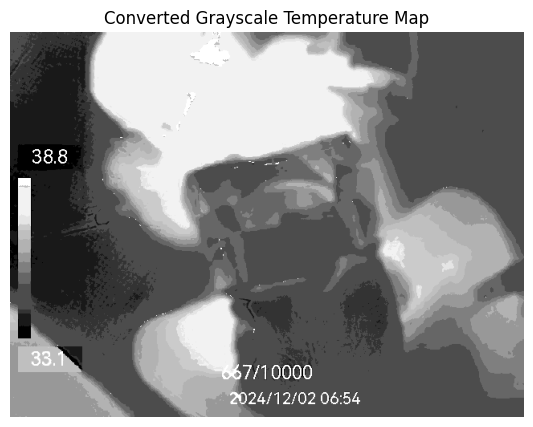

In [27]:
# Load the image
image_path = "/home/martina/codi2/3year/synthesisII/diferent/HM20241202065451.jpeg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

grayscale_image = color_to_temp_to_grayscale(image, 38.8, 33.1)

# Display the grayscale image
plt.figure(figsize=(10, 5))
plt.imshow(grayscale_image, cmap="gray")
plt.title("Converted Grayscale Temperature Map")
plt.axis("off")
plt.show()

ALL IMAGES IN THE "DIFFERENT" FOLDER

Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20240815055937.jpeg
coordinates - grayscale value - temperatures:
(129, 170) - Grayscale value: 229, Temperature: 37.2
(262, 215) - Grayscale value: 25, Temperature: 31.7
(398, 235) - Grayscale value: 51, Temperature: 32.4
(412, 421) - Grayscale value: 203, Temperature: 36.5
(84, 627) - Grayscale value: 101, Temperature: 33.7
   VALIDATION
   Lowest pixel value: 0 at coordinates (36, 0) - Normalized temperature: 31.0
   Highest pixel value: 255 at coordinates (85, 5) - Normalized temperature: 37.9


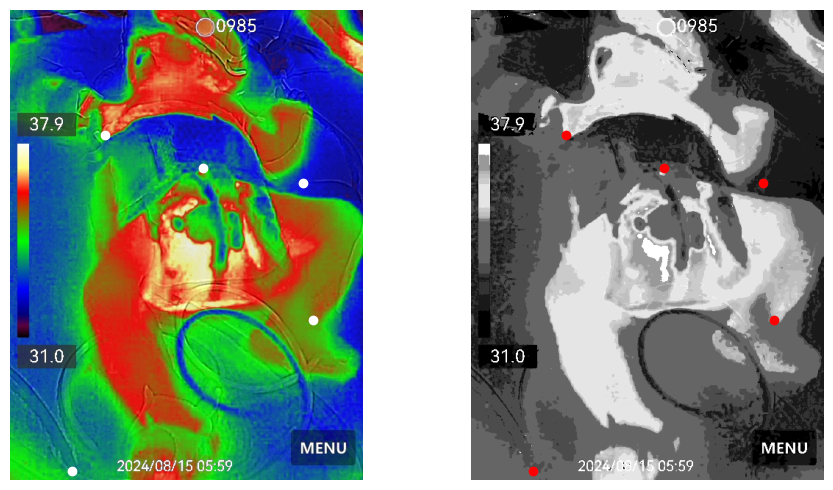

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20240815062318.jpeg
coordinates - grayscale value - temperatures:
(466, 3) - Grayscale value: 51, Temperature: 32.9
(387, 87) - Grayscale value: 25, Temperature: 32.0
(218, 173) - Grayscale value: 25, Temperature: 32.0
(44, 223) - Grayscale value: 51, Temperature: 32.9
(361, 453) - Grayscale value: 102, Temperature: 34.7
   VALIDATION
   Lowest pixel value: 0 at coordinates (37, 0) - Normalized temperature: 31.1
   Highest pixel value: 255 at coordinates (84, 5) - Normalized temperature: 40.2


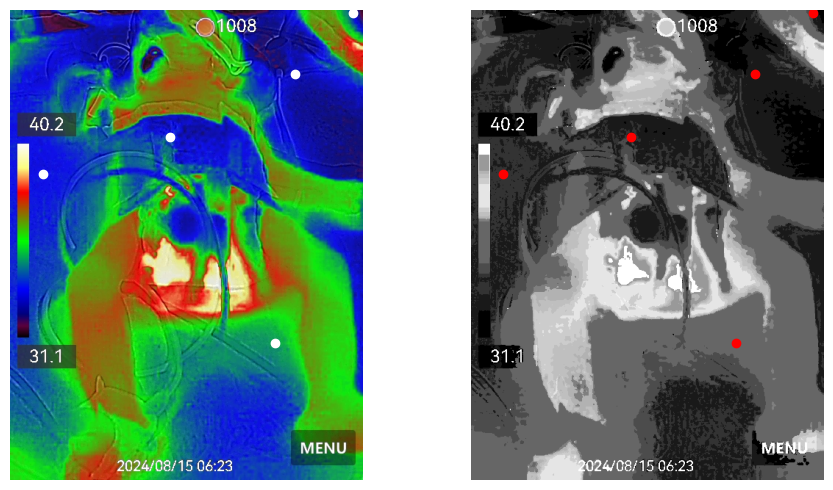

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202060956.jpeg
coordinates - grayscale value - temperatures:
(204, 180) - Grayscale value: 127, Temperature: 30.2
(157, 222) - Grayscale value: 178, Temperature: 33.2
(43, 261) - Grayscale value: 102, Temperature: 28.7
(576, 364) - Grayscale value: 242, Temperature: 36.9
(565, 432) - Grayscale value: 153, Temperature: 31.7
   VALIDATION
   Lowest pixel value: 0 at coordinates (206, 0) - Normalized temperature: 22.7
   Highest pixel value: 255 at coordinates (146, 0) - Normalized temperature: 37.7


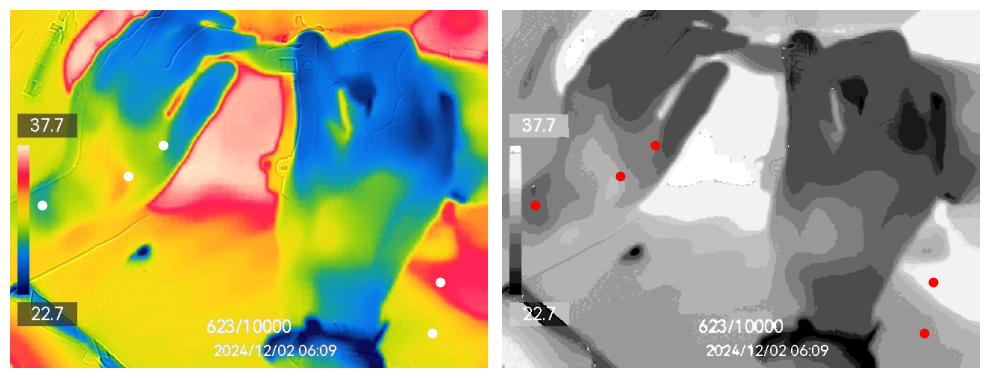

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202065451.jpeg
coordinates - grayscale value - temperatures:
(546, 94) - Grayscale value: 76, Temperature: 34.8
(628, 219) - Grayscale value: 76, Temperature: 34.8
(180, 336) - Grayscale value: 76, Temperature: 34.8
(502, 402) - Grayscale value: 76, Temperature: 34.8
(293, 449) - Grayscale value: 76, Temperature: 34.8
   VALIDATION
   Lowest pixel value: 0 at coordinates (11, 140) - Normalized temperature: 33.1
   Highest pixel value: 255 at coordinates (252, 0) - Normalized temperature: 38.8


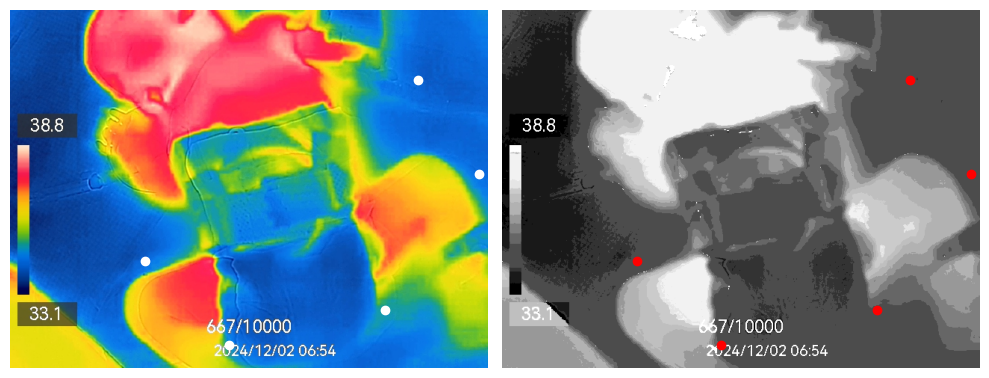

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202081023.jpeg
coordinates - grayscale value - temperatures:
(342, 105) - Grayscale value: 178, Temperature: 35.1
(168, 195) - Grayscale value: 191, Temperature: 35.7
(399, 384) - Grayscale value: 152, Temperature: 33.7
(484, 413) - Grayscale value: 0, Temperature: 26.0
(626, 459) - Grayscale value: 152, Temperature: 33.7
   VALIDATION
   Lowest pixel value: 0 at coordinates (12, 141) - Normalized temperature: 26.0
   Highest pixel value: 255 at coordinates (91, 8) - Normalized temperature: 39.0


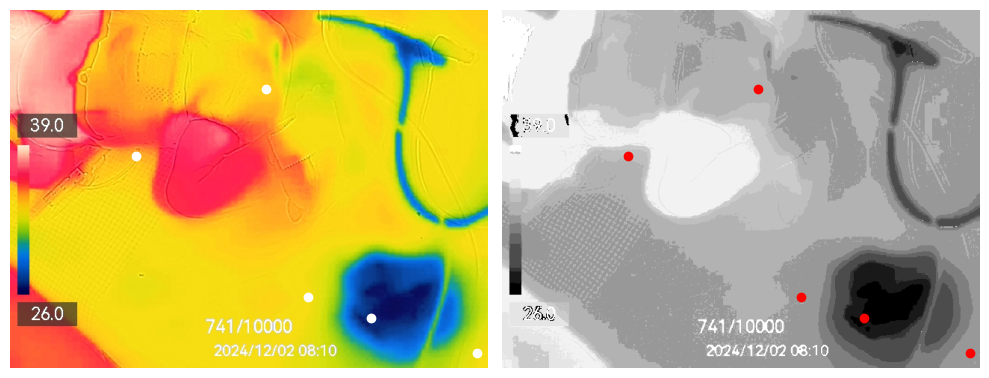

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202081529.jpeg
coordinates - grayscale value - temperatures:
(404, 33) - Grayscale value: 153, Temperature: 31.5
(234, 108) - Grayscale value: 242, Temperature: 35.3
(84, 317) - Grayscale value: 178, Temperature: 32.6
(614, 354) - Grayscale value: 153, Temperature: 31.5
(181, 396) - Grayscale value: 153, Temperature: 31.5
   VALIDATION
   Lowest pixel value: 0 at coordinates (304, 92) - Normalized temperature: 25.0
   Highest pixel value: 255 at coordinates (51, 24) - Normalized temperature: 35.9


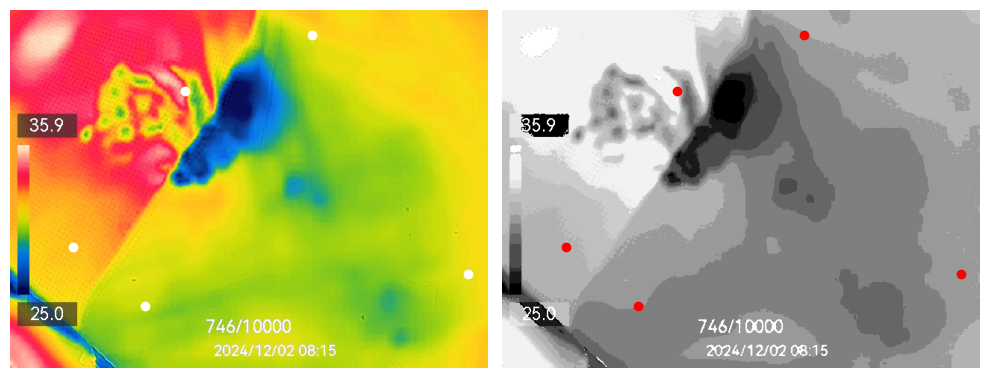

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202093407.jpeg
coordinates - grayscale value - temperatures:
(186, 211) - Grayscale value: 191, Temperature: 36.7
(328, 376) - Grayscale value: 127, Temperature: 34.8
(443, 419) - Grayscale value: 102, Temperature: 34.0
(18, 427) - Grayscale value: 191, Temperature: 36.7
(452, 436) - Grayscale value: 102, Temperature: 34.0
   VALIDATION
   Lowest pixel value: 0 at coordinates (28, 0) - Normalized temperature: 30.9
   Highest pixel value: 255 at coordinates (175, 0) - Normalized temperature: 38.7


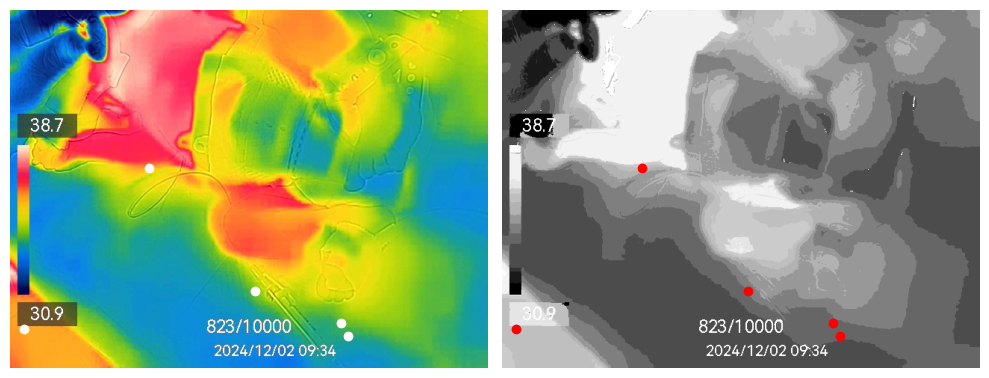

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202100444.jpeg
coordinates - grayscale value - temperatures:
(381, 19) - Grayscale value: 204, Temperature: 34.6
(77, 158) - Grayscale value: 191, Temperature: 33.6
(561, 202) - Grayscale value: 191, Temperature: 33.6
(156, 346) - Grayscale value: 127, Temperature: 28.7
(396, 346) - Grayscale value: 153, Temperature: 30.7
   VALIDATION
   Lowest pixel value: 0 at coordinates (89, 146) - Normalized temperature: 19.0
   Highest pixel value: 255 at coordinates (220, 0) - Normalized temperature: 38.5


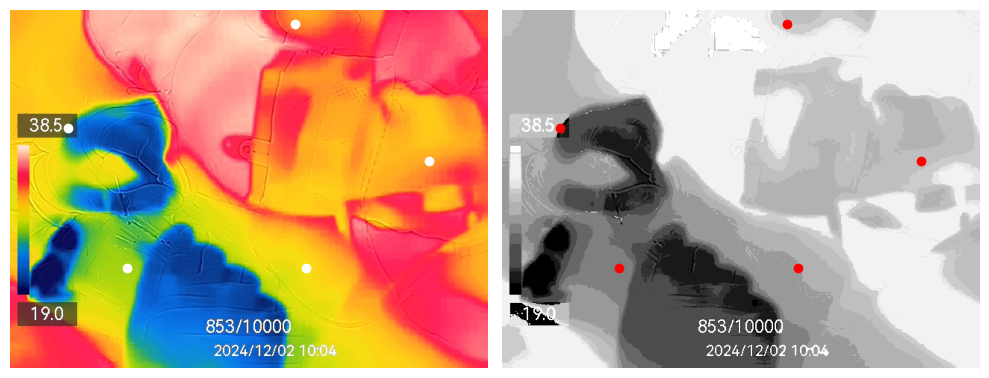

----------------------------------------------------------------------------------------------------


In [29]:
for path in image_paths[:]: 
    check_correlation(path)

7'57 min per 8 fotos

27 segons per 8 fotos - broadcasting (distances operation can be performed at once and without for loop) & parallel